# v6: Sparse Subspace Routing — Sparsity IS the Gate
## Content-Dependent Selectivity from Geometric Sparsity Alone

**Author:** David Ledbetter  
**Date:** 03/13/2026  
**Lineage:** Builds on architecture.ipynb (v1-v4.2) and v5_attention_gauge

---

### The Core Hypothesis

v3 showed that content-dependent cross-position selectivity is essential (35% vs 18-20%).  
v4 tried to get it from a content gate on top of causal convolution — didn't work.  
v5 tried QK attention-gauge + content gate — overfitted.

**v6 insight**: We've been trying to make the *mixing kernel* content-dependent.  
What if instead we make the *representations* so sparse that a content-independent kernel  
produces content-dependent mixing *emergently*?

If token 1 and token 10 share active fiber dimensions (overlapping sparse supports),  
their signals constructively interfere during causal convolution. If they don't share  
active dimensions, the multiplication hits zeros — no communication.

**The sparsity pattern IS the routing table.** No attention, no gate, no SSM.

### Key Architectural Changes from v4/v5

1. **No content gate** — removed. The sparsity does the gating.
2. **No QK attention-gauge** — removed. Gauge transport is position-based (MLP).
3. **Intermediate sparsification** — enforce sparsity BEFORE causal convolution,  
   so only shared subspaces communicate across positions.
4. **Settle-Mix-Settle block** — iterative structure:  
   - *Settle*: Langevin collapse establishes sparse subspace identity  
   - *Mix*: Causal convolution on sparse signals (shared dims interfere)  
   - *Settle*: Re-collapse incorporating cross-position information  
5. **Subspace alignment loss** — explicitly rewards adjacent tokens for sharing  
   subspace dimensions (learn sparse codes where related concepts overlap).

### The Bet

Can the Langevin settling + memory bank produce sparse codes where  
"things that should talk to each other" share active dimensions?  
If yes, we get content-dependent selectivity for free from the geometry.  
O(T log T), fully parallel, no pairwise comparisons.

| v4 (content-independent) | v5 (attention-gauge) | **v6 (sparse subspace)** |
|---|---|---|
| Same kernel for all tokens | QK-derived per-fiber phases | Same kernel for all tokens |
| Content gate scales output | Content gate scales output | **No gate** |
| Dense signal during mixing | Dense signal during mixing | **Sparse signal during mixing** |
| Routing in the kernel | Routing in gauge + gate | **Routing in the representations** |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from dataclasses import dataclass
import math
from tqdm.notebook import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


---
## 1. Configuration

Key changes from v4/v5:
- `settle_mix_rounds`: number of settle→mix iterations within each block  
- Higher `sparsity_lambda`: we need *harder* sparsity for the routing to be selective  
- `subspace_alignment_weight`: loss weight for encouraging sparse support overlap between adjacent tokens

In [2]:
@dataclass
class ArchitectureConfig:
    """Configuration for the Sparse Subspace Routing Architecture."""

    # --- Fiber Bundle Geometry ---
    fiber_dim: int = 128
    n_subbundles: int = 8
    manifold_dim: int = 64

    # --- Vocabulary & Embedding ---
    vocab_size: int = 256
    max_seq_len: int = 128

    # --- Sparse Dictionary ---
    n_dictionary_atoms: int = 512
    k_wta: int = 64

    # --- Spectral Transport ---
    diffusion_coeff: float = 0.01
    n_transport_layers: int = 3

    # --- Langevin Dynamics ---
    langevin_steps: int = 5
    langevin_lr: float = 0.1
    beta_init: float = 1.0
    beta_final: float = 10.0

    # --- Sparsity (HARDER than v4/v5 — sparsity IS the routing) ---
    sparsity_lambda: float = 0.4
    inhibition_gamma: float = 0.1

    # --- v6-specific ---
    settle_mix_rounds: int = 2       # settle→mix iterations per block
    subspace_alignment_weight: float = 0.05  # loss weight for support overlap

    # --- Training ---
    learning_rate: float = 5e-4
    dropout: float = 0.05
    batch_size: int = 32
    n_epochs: int = 150

    @property
    def subbundle_dim(self) -> int:
        assert self.fiber_dim % self.n_subbundles == 0
        return self.fiber_dim // self.n_subbundles


config = ArchitectureConfig()
print(f"Fiber dim: {config.fiber_dim} = {config.n_subbundles} subbundles x {config.subbundle_dim} dims each")
print(f"Dictionary: {config.n_dictionary_atoms} atoms, k-WTA selects {config.k_wta}")
print(f"Settle-mix rounds per block: {config.settle_mix_rounds}")
print(f"Sparsity lambda: {config.sparsity_lambda} (harder than v4/v5's 0.3)")

Fiber dim: 128 = 8 subbundles x 16 dims each
Dictionary: 512 atoms, k-WTA selects 64
Settle-mix rounds per block: 2
Sparsity lambda: 0.4 (harder than v4/v5's 0.3)


---
## 2. Foundation: Sparse Fiber Sections and Primitives

Shared with all architecture versions. Each token is a sparse section of the fiber bundle.  
The subbundle decomposition enforces orthogonal feature channels.

In [3]:
def soft_threshold(x: torch.Tensor, lam: float) -> torch.Tensor:
    """Proximal operator for L1 sparsity — lateral cortical inhibition."""
    return torch.sign(x) * F.relu(torch.abs(x) - lam)


def k_wta(x: torch.Tensor, k: int) -> torch.Tensor:
    """k-Winner-Take-All: retains top-k values, zeros the rest."""
    topk_vals, topk_idx = torch.topk(x, k, dim=-1)
    out = torch.zeros_like(x)
    out.scatter_(-1, topk_idx, topk_vals)
    return out


class SparseTokenEmbedding(nn.Module):
    """Maps vocabulary tokens to sparse fiber sections.

    Per-subbundle top-k sparsification enforces F_q = direct-sum F_q^(k).
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.fiber_dim)
        self.topk_per_subbundle = max(1, cfg.subbundle_dim // 4)
        self.manifold_coords = nn.Embedding(cfg.max_seq_len, cfg.manifold_dim)

    def forward(self, token_ids: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T = token_ids.shape
        x_dense = self.embedding(token_ids)

        chunks = x_dense.chunk(self.cfg.n_subbundles, dim=-1)
        sparse_chunks = []
        for chunk in chunks:
            topk_vals, topk_idx = torch.topk(
                chunk.abs(), self.topk_per_subbundle, dim=-1
            )
            mask = torch.zeros_like(chunk)
            mask.scatter_(-1, topk_idx, 1.0)
            sparse_chunks.append(chunk * mask)

        x_sparse = torch.cat(sparse_chunks, dim=-1)

        positions = torch.arange(T, device=token_ids.device)
        q_coords = self.manifold_coords(positions).unsqueeze(0).expand(B, -1, -1)

        return x_sparse, q_coords


embed = SparseTokenEmbedding(config)
test_ids = torch.randint(0, config.vocab_size, (2, 8))
x_sparse, q_coords = embed(test_ids)

sparsity = (x_sparse == 0).float().mean().item()
print(f"Sparse embedding shape: {x_sparse.shape}")
print(f"Sparsity ratio: {sparsity:.1%}")
print(f"Active dims per token: {(x_sparse != 0).float().sum(-1).mean().item():.0f} / {config.fiber_dim}")

Sparse embedding shape: torch.Size([2, 8, 128])
Sparsity ratio: 75.0%
Active dims per token: 32 / 128


---
## 3. Gauge Connection and Per-Fiber Transport

Position-based MLP gauge connection (same as v1-v4). No QK attention here —  
the content-dependence comes from the sparse representations, not the gauge field.  
The gauge field handles geometry (where things go), the sparsity handles routing (who talks to whom).

In [4]:
class GaugeConnection(nn.Module):
    """MLP-based gauge field A — position-dependent transport phases.

    Computes the holonomy phase and heat kernel for parallel transport
    from q_source to q_target on the base manifold.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.connection_net = nn.Sequential(
            nn.Linear(cfg.manifold_dim * 2, cfg.fiber_dim),
            nn.Tanh(),
        )
        self.log_diffusion = nn.Parameter(
            torch.full((cfg.fiber_dim,), math.log(cfg.diffusion_coeff))
        )

    def forward(
        self, q_source: torch.Tensor, q_target: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        q_pair = torch.cat([q_source, q_target], dim=-1)
        phase = self.connection_net(q_pair) * math.pi

        d = self.cfg.fiber_dim
        omega = torch.fft.fftfreq(d, device=q_source.device) * 2 * math.pi
        D = self.log_diffusion.exp()
        diffusion_kernel = torch.exp(-D * omega ** 2)
        diffusion_kernel = diffusion_kernel.expand_as(phase)

        return phase, diffusion_kernel

---
## 4. Dynamic Memory Bank

Geometrically-gated overcomplete dictionary. Same as v4/v5 —  
this is the attractor landscape that the Langevin dynamics settles into.

In [5]:
class DynamicMemoryBank(nn.Module):
    """Geometrically-gated overcomplete sparse dictionary.

    M_q = D[top-k(W_route @ q)] — the local memory bank at coordinate q.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.dictionary = nn.Parameter(
            torch.randn(cfg.n_dictionary_atoms, cfg.fiber_dim) * 0.02
        )
        self.router = nn.Sequential(
            nn.Linear(cfg.manifold_dim, cfg.n_dictionary_atoms),
            nn.SiLU(),
            nn.Linear(cfg.n_dictionary_atoms, cfg.n_dictionary_atoms),
        )

    def forward(self, q: torch.Tensor) -> torch.Tensor:
        D_normed = F.normalize(self.dictionary, dim=-1)
        gate_logits = self.router(q)
        _, topk_idx = torch.topk(gate_logits, self.cfg.k_wta, dim=-1)
        M_q = D_normed[topk_idx]
        return M_q

---
## 5. Langevin-Hopfield Settling

Annealed Langevin dynamics on the Modern Hopfield energy landscape.  
Collapses a dense/diffused signal into a sharp sparse attractor.

In v6 this is *critical* — the quality of the sparse codes determines  
whether the subspace routing works. Better sparsity = better routing selectivity.

In [6]:
class LangevinHopfieldDescent(nn.Module):
    """Annealed Langevin dynamics with proximal sparsity projection."""

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.W_inh = nn.Parameter(
            torch.randn(cfg.fiber_dim, cfg.fiber_dim) * 0.01
        )

    def hopfield_gradient(self, x, M_q, beta):
        similarities = torch.bmm(M_q, x.unsqueeze(-1)).squeeze(-1)
        weights = F.softmax(beta * similarities, dim=-1)
        weighted_memories = torch.bmm(weights.unsqueeze(1), M_q).squeeze(1)
        return -weighted_memories

    def hopfield_energy(self, x, M_q, beta):
        similarities = torch.bmm(M_q, x.unsqueeze(-1)).squeeze(-1)
        return -(1.0 / beta) * torch.logsumexp(beta * similarities, dim=-1)

    def forward(self, x_noisy, M_q, return_trajectory=False):
        cfg = self.cfg
        x = x_noisy.clone()
        trajectory = [x.detach().clone()] if return_trajectory else None
        betas = torch.linspace(cfg.beta_init, cfg.beta_final, cfg.langevin_steps)

        for step in range(cfg.langevin_steps):
            beta_t = betas[step].item()
            grad_E = self.hopfield_gradient(x, M_q, beta_t)
            inhibition = cfg.inhibition_gamma * (x @ self.W_inh.T)
            noise_scale = math.sqrt(2.0 * cfg.langevin_lr / beta_t)
            noise = noise_scale * torch.randn_like(x)

            x = x - cfg.langevin_lr * grad_E - inhibition + noise
            x = soft_threshold(x, cfg.sparsity_lambda * cfg.langevin_lr)

            if return_trajectory:
                trajectory.append(x.detach().clone())

        if return_trajectory:
            return x, trajectory
        return x

---
## 6. The Sparse Subspace Transport Operator

### The Core v6 Innovation

This replaces v4's `SpectralTransportOperator` and v5's attention-gauge version.

**The fundamental restructuring:**

v4/v5 flow: `gauge_transport → causal_conv [on dense signal] → content_gate → settle`  
v6 flow: `gauge_transport → SPARSIFY → causal_conv [on sparse signal] → no gate needed`

By enforcing sparsity *before* the causal convolution, we guarantee that  
cross-position mixing only occurs along shared subspace dimensions.  
Tokens with disjoint sparse supports can't communicate — the zeros block it.  
Tokens with overlapping supports constructively interfere.

The **content gate is removed entirely**. No learned routing parameters.  
The routing is purely geometric: it lives in the sparse representation structure.

In [7]:
class SparseSubspaceTransport(nn.Module):
    """Cross-position mixing where sparsity IS the routing mechanism.

    Two stages:
      Stage 1 — Per-fiber gauge transport: FFT over fiber_dim applies
        advection-diffusion (Wilson line holonomy + heat kernel).
        This is geometry-aware but content-independent.

      Stage 2 — Sparse causal convolution: enforce sparsity via
        soft-thresholding, THEN apply causal convolution via FFT
        over the sequence dimension. Only shared subspace dimensions
        constructively interfere across positions.

    No content gate. No attention. The sparsity pattern is the gate.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.gauge = GaugeConnection(cfg)

        self.log_decay = nn.Parameter(
            torch.linspace(-1.0, 2.0, cfg.fiber_dim)
        )

        self.norm = nn.LayerNorm(cfg.fiber_dim)

    def forward(self, x_seq, q_coords):
        B, T, D = x_seq.shape

        # --- Stage 1: Per-fiber gauge transport ---
        q_next = torch.roll(q_coords, -1, dims=1)
        q_next[:, -1] = q_coords[:, -1]

        phase_all, diff_all = self.gauge(
            q_coords.reshape(-1, q_coords.size(-1)),
            q_next.reshape(-1, q_next.size(-1)),
        )
        phase_all = phase_all.reshape(B, T, D)
        diff_all = diff_all.reshape(B, T, D)

        wilson = torch.cumsum(phase_all, dim=1)

        omega = torch.fft.fftfreq(D, device=x_seq.device) * 2 * math.pi
        gauge_rot = torch.exp(-1j * omega * wilson)

        X_fiber = torch.fft.fft(x_seq, dim=-1)
        X_transported = X_fiber * diff_all.to(X_fiber.dtype) * gauge_rot
        x_gauge = torch.fft.ifft(X_transported, dim=-1).real

        # --- THE v6 KEY: Enforce sparsity BEFORE cross-position mixing ---
        x_sparse_pre_mix = soft_threshold(x_gauge, self.cfg.sparsity_lambda)

        # --- Stage 2: Causal convolution on SPARSE signals ---
        decay = F.softplus(self.log_decay)
        lags = torch.arange(T, device=x_seq.device).float()
        causal_kernel = torch.exp(-decay.unsqueeze(0) * lags.unsqueeze(-1))
        causal_kernel = causal_kernel / (causal_kernel.sum(dim=0, keepdim=True) + 1e-8)

        x_padded = F.pad(x_sparse_pre_mix, (0, 0, 0, T))
        k_padded = F.pad(causal_kernel, (0, 0, 0, T))

        X_seq = torch.fft.fft(x_padded, dim=1)
        K_seq = torch.fft.fft(k_padded, dim=0).unsqueeze(0)

        Y_seq = X_seq * K_seq
        x_mixed = torch.fft.ifft(Y_seq, dim=1).real[:, :T, :]

        # No content gate — the sparsity did the routing
        x_out = self.norm(x_mixed + x_seq)

        return x_out, wilson


transport = SparseSubspaceTransport(config)
x_test = x_sparse[:1]
q_test = q_coords[:1]
x_out, wilson = transport(x_test, q_test)

pre_mix_sparsity = (soft_threshold(x_test, config.sparsity_lambda) == 0).float().mean().item()
print(f"Input shape:  {x_test.shape}")
print(f"Output shape: {x_out.shape}")
print(f"Sparsity before mixing: {pre_mix_sparsity:.1%}")
print(f"No content gate, no attention — sparsity IS the routing")

Input shape:  torch.Size([1, 8, 128])
Output shape: torch.Size([1, 8, 128])
Sparsity before mixing: 75.0%
No content gate, no attention — sparsity IS the routing


---
## 7. The Settle-Mix-Settle Block

### Iterative Sparse Subspace Message Passing

The core structural innovation of v6. Instead of a single transport→settle pass,  
we iterate:

1. **Settle** — Langevin descent collapses state to a sparse attractor.  
   This establishes the token's *subspace identity*: which fiber dimensions are active.

2. **Mix** — Causal convolution on the sparse signals.  
   Only tokens sharing active dimensions exchange information.  
   The sparse support acts as a filter/gate.

3. **Settle** — Re-collapse incorporating the cross-position information.  
   The new information may shift which attractor the token falls into,  
   potentially changing its sparse support for the next round.

Each round refines both the sparse codes and the cross-position routing.  
This is geometric message passing where the messages are filtered by subspace overlap.

In [8]:
class SettleMixSettleBlock(nn.Module):
    """Iterative settle-mix-settle block with sparse subspace routing.

    Each round:
      1. Langevin settle -> establish sparse subspace identity
      2. Sparse causal conv -> cross-position mixing filtered by sparsity
      3. Repeat for settle_mix_rounds iterations

    Final settle produces the block output.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.transport = SparseSubspaceTransport(cfg)
        self.memory_bank = DynamicMemoryBank(cfg)
        self.langevin = LangevinHopfieldDescent(cfg)
        self.dropout = nn.Dropout(cfg.dropout)

    def _settle(self, x_seq, q_coords):
        """Langevin settle all positions in parallel."""
        B, T, D = x_seq.shape
        q_flat = q_coords.reshape(B * T, -1)
        M_q = self.memory_bank(q_flat)
        x_flat = x_seq.reshape(B * T, D)
        x_settled = self.langevin(x_flat, M_q)
        return x_settled.reshape(B, T, D)

    def forward(self, x_seq, q_coords):
        B, T, D = x_seq.shape
        x = x_seq
        wilson = None

        for round_idx in range(self.cfg.settle_mix_rounds):
            # SETTLE: collapse to sparse attractor (subspace identity)
            x_settled = self._settle(x, q_coords)

            # MIX: causal convolution on sparse signals
            # Sparsity from the settle step filters the communication
            x_mixed, wilson = self.transport(x_settled, q_coords)

            # Residual from round input for gradient flow
            x = x_mixed + x * (0.5 ** (round_idx + 1))

        # Final settle to produce clean sparse output
        x_final = self._settle(x, q_coords)
        x_final = self.dropout(x_final) + x_seq

        return x_final, wilson


block = SettleMixSettleBlock(config)
x_block_out, w = block(x_sparse[:1], q_coords[:1])
print(f"Block input sparsity:  {(x_sparse[:1] == 0).float().mean().item():.1%}")
print(f"Block output sparsity: {(x_block_out == 0).float().mean().item():.1%}")
print(f"Settle-mix rounds: {config.settle_mix_rounds}")

Block input sparsity:  75.0%
Block output sparsity: 9.4%
Settle-mix rounds: 2


---
## 8. Subspace Overlap Diagnostics

For the sparse subspace routing to work, we need to verify that:
1. Adjacent tokens in learnable sequences develop overlapping sparse supports
2. Unrelated tokens have disjoint supports
3. The overlap pattern reflects the sequence structure

We define a **support overlap** metric: the Jaccard similarity of the non-zero  
indices between two sparse vectors. This measures how much two tokens can  
communicate through the causal convolution.

=== BEFORE settle-mix-settle (raw embedding) ===


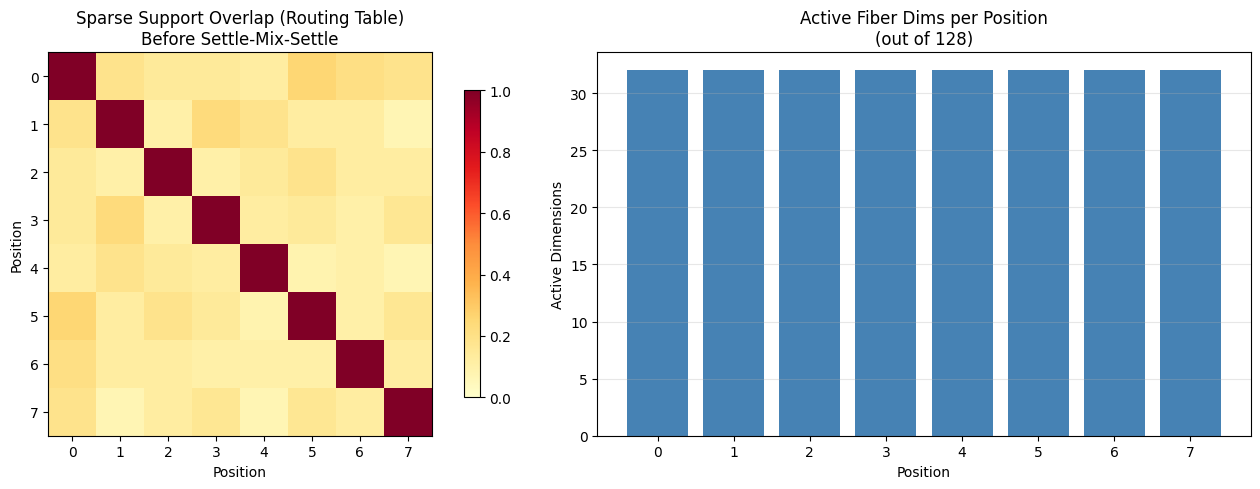


=== AFTER settle-mix-settle (learned routing) ===


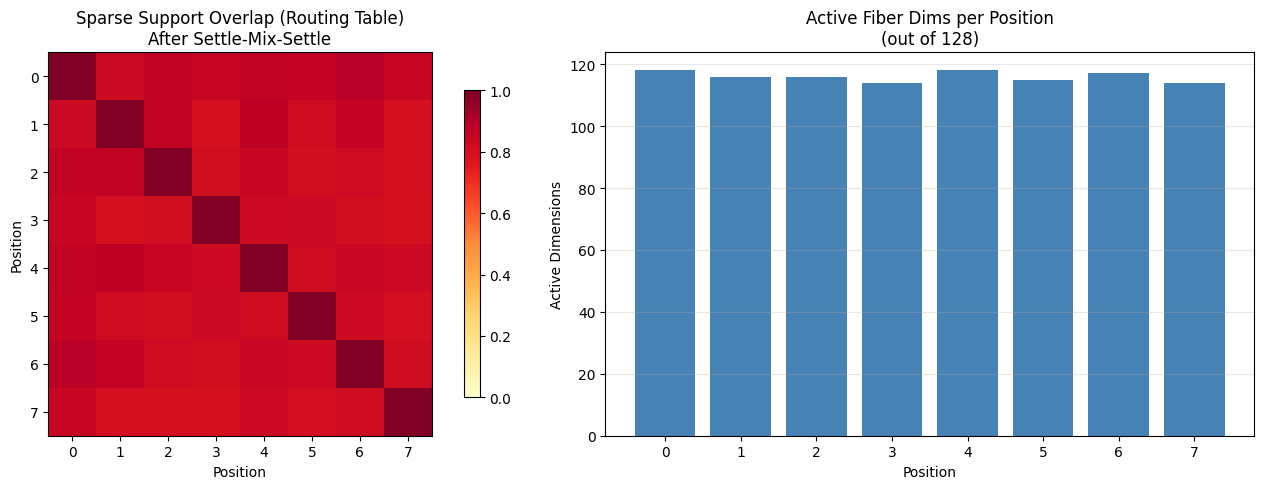

In [9]:
def sparse_support_overlap(x1: torch.Tensor, x2: torch.Tensor) -> float:
    """Jaccard similarity of non-zero supports between two sparse vectors.

    Returns 1.0 if identical supports, 0.0 if completely disjoint.
    This quantifies how much two tokens can communicate via sparse routing.
    """
    s1 = (x1.abs() > 1e-6).float()
    s2 = (x2.abs() > 1e-6).float()
    intersection = (s1 * s2).sum()
    union = ((s1 + s2) > 0).float().sum()
    if union < 1e-8:
        return 0.0
    return (intersection / union).item()


def analyze_subspace_routing(x_seq: torch.Tensor, title: str = ""):
    """Visualize the sparse support overlap matrix for a sequence.

    This is the 'routing table' — it shows which positions can communicate.
    """
    T = x_seq.shape[0]
    overlap_matrix = torch.zeros(T, T)
    for i in range(T):
        for j in range(T):
            overlap_matrix[i, j] = sparse_support_overlap(x_seq[i], x_seq[j])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im = axes[0].imshow(overlap_matrix.numpy(), cmap='YlOrRd', vmin=0, vmax=1)
    axes[0].set_xlabel('Position')
    axes[0].set_ylabel('Position')
    axes[0].set_title(f'Sparse Support Overlap (Routing Table)\n{title}')
    plt.colorbar(im, ax=axes[0], shrink=0.8)

    # Active dimensions per position
    active_counts = (x_seq.abs() > 1e-6).float().sum(-1).numpy()
    axes[1].bar(range(T), active_counts, color='steelblue')
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('Active Dimensions')
    axes[1].set_title(f'Active Fiber Dims per Position\n(out of {x_seq.shape[-1]})')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return overlap_matrix


with torch.no_grad():
    x_init_seq = x_sparse[0]  # (T, D) — initial sparse embeddings
    x_settled_seq = x_block_out[0]  # (T, D) — after settle-mix-settle

print("=== BEFORE settle-mix-settle (raw embedding) ===")
overlap_before = analyze_subspace_routing(x_init_seq, "Before Settle-Mix-Settle")

print("\n=== AFTER settle-mix-settle (learned routing) ===")
overlap_after = analyze_subspace_routing(x_settled_seq, "After Settle-Mix-Settle")

---
## 9. The Complete CLM with Subspace Alignment Loss

The full causal language model, plus a new loss component that  
incentivizes the architecture to learn sparse codes where  
sequentially adjacent tokens share subspace dimensions.

### Subspace Alignment Loss

For a sequence, we want tokens at positions t and t+1 to have  
overlapping sparse supports (so they can communicate through  
the causal convolution). We penalize when adjacent tokens have  
completely disjoint supports:

    L_align = -mean( support(x_t) . support(x_{t+1}) )

This is a differentiable approximation using the soft support  
(absolute values) rather than hard binary masks.

In [10]:
class SpectralGaugeCLM(nn.Module):
    """Causal Language Model with Sparse Subspace Routing.

    v6: No content gate, no attention. Sparsity IS the routing.
    Settle-mix-settle blocks produce sparse codes where cross-position
    communication is filtered by subspace overlap.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = SparseTokenEmbedding(cfg)
        self.blocks = nn.ModuleList([
            SettleMixSettleBlock(cfg) for _ in range(cfg.n_transport_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.fiber_dim, cfg.vocab_size),
        )

    def subspace_alignment_loss(self, x_seq: torch.Tensor) -> torch.Tensor:
        """Encourage adjacent tokens to share sparse support dimensions.

        Uses soft support (absolute values) for differentiability.
        Adjacent tokens with overlapping supports can communicate
        through the causal convolution; disjoint supports block communication.
        """
        soft_support = torch.sigmoid(10.0 * (x_seq.abs() - 0.01))
        # Overlap between position t and t+1
        support_t = soft_support[:, :-1, :]   # (B, T-1, D)
        support_tp1 = soft_support[:, 1:, :]  # (B, T-1, D)
        # Dot product of support indicators (high when shared dims)
        overlap = (support_t * support_tp1).sum(dim=-1)  # (B, T-1)
        # Normalize by geometric mean of support sizes
        size_t = support_t.sum(dim=-1).clamp(min=1.0)
        size_tp1 = support_tp1.sum(dim=-1).clamp(min=1.0)
        normalized_overlap = overlap / torch.sqrt(size_t * size_tp1)
        # Maximize overlap -> minimize negative
        return -normalized_overlap.mean()

    def forward(self, token_ids: torch.Tensor) -> Tuple[torch.Tensor, dict]:
        B, T = token_ids.shape

        x_sparse, q_coords = self.embedding(token_ids)

        x = x_sparse
        wilson = None
        for block in self.blocks:
            x, wilson = block(x, q_coords)

        # Compute subspace alignment on the final settled representations
        alignment_loss = self.subspace_alignment_loss(x)

        logits = self.decoder(x)
        logits = logits[:, :-1, :]

        info = {
            "mean_sparsity": (x == 0).float().mean().item(),
            "alignment_loss": alignment_loss.item(),
            "wilson_phase_norm": wilson.norm().item() if wilson is not None else 0.0,
        }

        return logits, info, alignment_loss


model = SpectralGaugeCLM(config).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nBlocks: {config.n_transport_layers} x (settle-mix-settle, {config.settle_mix_rounds} rounds each)")
print(f"Total settle passes: {config.n_transport_layers * (config.settle_mix_rounds + 1)}")
print(f"No content gate params, no QK attention params")

Total parameters: 1,275,136
Trainable parameters: 1,275,136

Blocks: 3 x (settle-mix-settle, 2 rounds each)
Total settle passes: 9
No content gate params, no QK attention params


---
## 10. Training

Same synthetic task as v4/v5 for direct comparison.  
Loss has four components:
1. Cross-entropy (next-token prediction)
2. Dictionary coherence (prevent atom collapse)
3. L1 sparsity penalty
4. **Subspace alignment** (new in v6 — encourage support overlap between adjacent tokens)

In [11]:
def generate_synthetic_data(n_samples, seq_len, vocab_size, n_patterns=8):
    """Same synthetic data as v4/v5 for direct comparison."""
    data = torch.zeros(n_samples, seq_len, dtype=torch.long)

    for i in range(n_samples):
        pattern_type = i % n_patterns

        if pattern_type < 3:
            start = torch.randint(0, vocab_size, (1,)).item()
            step = (pattern_type + 1) * 7
            for t in range(seq_len):
                data[i, t] = (start + t * step) % vocab_size

        elif pattern_type < 5:
            k = pattern_type + 1
            motif = torch.randint(0, vocab_size, (k,))
            for t in range(seq_len):
                data[i, t] = motif[t % k]

        elif pattern_type < 7:
            data[i, 0] = torch.randint(0, vocab_size, (1,))
            data[i, 1] = torch.randint(0, vocab_size, (1,))
            for t in range(2, seq_len):
                data[i, t] = (data[i, t-1].item() ^ data[i, t-2].item()) % vocab_size

        else:
            increments = torch.randint(1, 10, (seq_len,))
            data[i] = torch.cumsum(increments, dim=0) % vocab_size

    return data


seq_len = 16
train_data = generate_synthetic_data(4096, seq_len, config.vocab_size)
val_data = generate_synthetic_data(512, seq_len, config.vocab_size)

print(f"Training data: {train_data.shape}")
print(f"Validation data: {val_data.shape}")
print(f"Sample: {train_data[0].tolist()}")

Training data: torch.Size([4096, 16])
Validation data: torch.Size([512, 16])
Sample: [147, 154, 161, 168, 175, 182, 189, 196, 203, 210, 217, 224, 231, 238, 245, 252]


In [12]:
def train_epoch(model, data, optimizer, cfg):
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_align = 0.0
    n_batches = 0

    perm = torch.randperm(data.size(0))
    data = data[perm]

    for i in range(0, len(data) - cfg.batch_size + 1, cfg.batch_size):
        batch = data[i : i + cfg.batch_size].to(device)
        optimizer.zero_grad()

        logits, info, alignment_loss = model(batch)
        targets = batch[:, 1:]

        ce_loss = F.cross_entropy(
            logits.reshape(-1, cfg.vocab_size), targets.reshape(-1)
        )

        dict_coherence_loss = 0.0
        for block in model.blocks:
            D = F.normalize(block.memory_bank.dictionary, dim=-1)
            gram = D @ D.T
            eye = torch.eye(gram.size(0), device=gram.device)
            dict_coherence_loss = dict_coherence_loss + (gram - eye).pow(2).mean()
        dict_coherence_loss = dict_coherence_loss / len(model.blocks)

        sparsity_loss = logits.abs().mean()

        loss = (
            ce_loss
            + 0.1 * dict_coherence_loss
            + 0.01 * sparsity_loss
            + cfg.subspace_alignment_weight * alignment_loss
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_align += alignment_loss.item()
        n_batches += 1

    return total_loss / n_batches, total_ce / n_batches, total_align / n_batches


@torch.no_grad()
def evaluate(model, data, cfg):
    model.eval()
    total_ce = 0.0
    total_correct = 0
    total_tokens = 0
    n_batches = 0

    for i in range(0, len(data) - cfg.batch_size + 1, cfg.batch_size):
        batch = data[i : i + cfg.batch_size].to(device)
        logits, info, _ = model(batch)
        targets = batch[:, 1:]

        ce_loss = F.cross_entropy(
            logits.reshape(-1, cfg.vocab_size), targets.reshape(-1)
        )
        total_ce += ce_loss.item()

        preds = logits.argmax(dim=-1)
        total_correct += (preds == targets).sum().item()
        total_tokens += targets.numel()
        n_batches += 1

    avg_ce = total_ce / max(n_batches, 1)
    accuracy = total_correct / max(total_tokens, 1)
    return avg_ce, accuracy


optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=0.02)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.n_epochs)

history = {"train_loss": [], "train_ce": [], "val_ce": [], "val_acc": [], "alignment": []}

print("Training Sparse Subspace Routing CLM (v6)...")
print("=" * 70)

pbar = tqdm(range(config.n_epochs), desc="Training", unit="epoch")
for epoch in pbar:
    train_loss, train_ce, align_loss = train_epoch(model, train_data, optimizer, config)
    val_ce, val_acc = evaluate(model, val_data, config)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_ce"].append(train_ce)
    history["val_ce"].append(val_ce)
    history["val_acc"].append(val_acc)
    history["alignment"].append(align_loss)

    tqdm.write(
        f"Epoch {epoch+1:3d}/{config.n_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"CE: {train_ce:.4f} | "
        f"Val CE: {val_ce:.4f} | "
        f"Val Acc: {val_acc:.2%} | "
        f"Align: {align_loss:.4f}"
    )

print("=" * 70)
print("Training complete.")

Training Sparse Subspace Routing CLM (v6)...


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Epoch   1/150 | Loss: 5.4849 | CE: 5.5254 | Val CE: 5.1241 | Val Acc: 8.46% | Align: -0.9711
Epoch   2/150 | Loss: 4.7977 | CE: 4.8369 | Val CE: 4.7927 | Val Acc: 13.05% | Align: -0.9717
Epoch   3/150 | Loss: 4.4756 | CE: 4.5127 | Val CE: 4.6547 | Val Acc: 14.13% | Align: -0.9727
Epoch   4/150 | Loss: 4.3076 | CE: 4.3436 | Val CE: 4.6019 | Val Acc: 15.13% | Align: -0.9731
Epoch   5/150 | Loss: 4.1980 | CE: 4.2333 | Val CE: 4.5789 | Val Acc: 14.37% | Align: -0.9735
Epoch   6/150 | Loss: 4.1100 | CE: 4.1447 | Val CE: 4.5856 | Val Acc: 14.58% | Align: -0.9739


KeyboardInterrupt: 

---
## 11. Training Diagnostics

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history["train_loss"], 'b-', label='Total Loss')
axes[0, 0].plot(history["train_ce"], 'b--', alpha=0.6, label='CE Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history["val_ce"], 'r-')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Cross-Entropy')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(history["val_acc"], 'g-')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Accuracy')
axes[0, 2].set_title('Validation Accuracy')
axes[0, 2].axhline(y=1.0/config.vocab_size, color='gray', linestyle='--',
                    label=f'Random ({1.0/config.vocab_size:.2%})')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(history["alignment"], 'purple')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Alignment Loss')
axes[1, 0].set_title('Subspace Alignment Loss\n(lower = more overlap between adjacent tokens)')
axes[1, 0].grid(True, alpha=0.3)

# Dictionary gram matrix
with torch.no_grad():
    D = F.normalize(model.blocks[0].memory_bank.dictionary, dim=-1)
    gram = (D @ D.T).cpu().numpy()

im = axes[1, 1].imshow(gram[:50, :50], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('Dictionary Gram Matrix (first 50 atoms)')
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

# Post-training routing analysis
with torch.no_grad():
    test_batch = val_data[:1].to(device)
    _, info, _ = model(test_batch)
    x_sp, q_c = model.embedding(test_batch)
    x_final = x_sp
    for blk in model.blocks:
        x_final, _ = blk(x_final, q_c)

    T = x_final.shape[1]
    overlap = torch.zeros(T, T)
    for i in range(T):
        for j in range(T):
            overlap[i, j] = sparse_support_overlap(x_final[0, i], x_final[0, j])

im2 = axes[1, 2].imshow(overlap.numpy(), cmap='YlOrRd', vmin=0, vmax=1)
axes[1, 2].set_xlabel('Position')
axes[1, 2].set_ylabel('Position')
axes[1, 2].set_title('Learned Routing Table\n(Sparse Support Overlap After Training)')
plt.colorbar(im2, ax=axes[1, 2], shrink=0.8)

plt.suptitle('v6: Sparse Subspace Routing — Training Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Autoregressive Generation

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=20):
    model.eval()
    cfg = model.cfg
    device = next(model.parameters()).device
    sequence = prompt.to(device)

    for step in range(max_new_tokens):
        T = sequence.size(1)
        if T >= cfg.max_seq_len:
            break

        logits, _, _ = model(sequence)
        next_logits = logits[:, -1, :]
        next_token = next_logits.argmax(dim=-1, keepdim=True)
        sequence = torch.cat([sequence, next_token], dim=1)

    return sequence


print("Autoregressive Generation (v6: Sparse Subspace Routing)")
print("=" * 55)

for i in range(5):
    prompt = val_data[i, :4].unsqueeze(0)
    ground_truth = val_data[i].tolist()

    generated = generate(model, prompt, max_new_tokens=12)
    gen_list = generated[0].tolist()

    print(f"\nExample {i+1}:")
    print(f"  Prompt:       {ground_truth[:4]}")
    print(f"  Ground truth: {ground_truth}")
    print(f"  Generated:    {gen_list}")
    matches = sum(a == b for a, b in zip(gen_list[4:], ground_truth[4:]))
    print(f"  Match rate:   {matches}/{min(len(gen_list)-4, len(ground_truth)-4)} correct")

---
## 13. Geometric Analysis: Visualizing Sparse Subspace Routing

The key diagnostic for v6: do the learned sparse codes create meaningful  
routing structure? We examine:

1. **Support overlap vs. position distance** — do nearby tokens share more subspace dims?
2. **Support overlap vs. pattern type** — do tokens from the same pattern family share dims?
3. **Routing selectivity** — how binary is the overlap? (ideal: either high overlap or zero)
4. **Settle-mix trajectory** — how does the routing table evolve across settle-mix rounds?

In [ ]:
@torch.no_grad()
def analyze_routing_geometry(model, data, cfg):
    model.eval()
    device = next(model.parameters()).device
    batch = data[:8].to(device)

    x_sparse, q_coords = model.embedding(batch)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    # --- 1. Wilson Line Phase Accumulation ---
    block = model.blocks[0]
    x_settled = block._settle(x_sparse[:1], q_coords[:1])
    _, wilson = block.transport(x_settled, q_coords[:1])

    wilson_arr = wilson[0].cpu().numpy()
    im1 = axes[0, 0].imshow(wilson_arr.T[:32, :], aspect='auto', cmap='twilight')
    axes[0, 0].set_xlabel('Sequence Position')
    axes[0, 0].set_ylabel('Fiber Dimension')
    axes[0, 0].set_title('Wilson Line Phase Accumulation')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    # --- 2. Pre-mix sparsity visualization ---
    x_pre_mix = soft_threshold(
        torch.fft.ifft(
            torch.fft.fft(x_settled, dim=-1), dim=-1
        ).real,
        cfg.sparsity_lambda
    )
    pre_mix_arr = x_pre_mix[0].cpu().numpy()
    im2 = axes[0, 1].imshow(pre_mix_arr.T[:64], aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[0, 1].set_xlabel('Position')
    axes[0, 1].set_ylabel('Fiber Dim')
    axes[0, 1].set_title('Pre-Mix Sparse Sections\n(These ARE the routing masks)')
    plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)

    # --- 3. Support overlap as function of position distance ---
    x_final = x_sparse[:4]
    for blk in model.blocks:
        x_final, _ = blk(x_final, q_coords[:4])

    distances = []
    overlaps = []
    T = x_final.shape[1]
    for b in range(min(4, x_final.shape[0])):
        for i in range(T):
            for j in range(i+1, T):
                distances.append(j - i)
                overlaps.append(sparse_support_overlap(x_final[b, i], x_final[b, j]))

    axes[0, 2].scatter(distances, overlaps, alpha=0.3, s=8, color='steelblue')
    axes[0, 2].set_xlabel('Position Distance |i - j|')
    axes[0, 2].set_ylabel('Sparse Support Overlap')
    axes[0, 2].set_title('Support Overlap vs. Distance\n(Does proximity predict routing?)')
    axes[0, 2].grid(True, alpha=0.3)

    # --- 4. Routing selectivity histogram ---
    axes[1, 0].hist(overlaps, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Sparse Support Overlap')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Routing Selectivity Distribution\n(Bimodal = selective routing)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # --- 5. Settled activation patterns ---
    settled_arr = x_final[0].cpu().numpy()
    im5 = axes[1, 1].imshow(settled_arr.T, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[1, 1].set_xlabel('Position')
    axes[1, 1].set_ylabel('Fiber Dim')
    axes[1, 1].set_title('Final Settled Sparse Sections')
    for k in range(1, cfg.n_subbundles):
        axes[1, 1].axhline(y=k * cfg.subbundle_dim - 0.5, color='white',
                           linewidth=1.0, linestyle='--', alpha=0.6)
    plt.colorbar(im5, ax=axes[1, 1], shrink=0.8)

    # --- 6. Active dims per position ---
    active_counts = (x_final[0].abs() > 1e-6).float().sum(-1).cpu().numpy()
    axes[1, 2].bar(range(T), active_counts, color='steelblue')
    axes[1, 2].set_xlabel('Position')
    axes[1, 2].set_ylabel('Active Dims')
    axes[1, 2].set_title(f'Active Fiber Dims per Position (of {cfg.fiber_dim})')
    axes[1, 2].axhline(y=cfg.fiber_dim, color='red', linestyle='--', alpha=0.5, label='Total')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    axes[1, 2].legend()

    plt.suptitle('v6: Sparse Subspace Routing — Geometric Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


analyze_routing_geometry(model, val_data, config)

---
## 14. Summary

### v6 Architecture: Sparse Subspace Routing

```
Input Token IDs: [t_1, t_2, ..., t_T]
        |
        v
[Sparse Token Embedding] → sparse fiber sections + manifold coordinates
        |
        v
For each SettleMixSettle block (x n_transport_layers):
  |
  For each round (x settle_mix_rounds):
  |
  |  [SETTLE] Langevin-Hopfield descent → sharp sparse code
  |     ↓ Establishes which subspace dimensions are active
  |     ↓ THIS IS THE ROUTING MASK
  |
  |  [SPARSIFY] Soft-threshold BEFORE mixing
  |     ↓ Zeros block communication on inactive dims
  |
  |  [MIX] Causal convolution on SPARSE signals (FFT over seq dim)
  |     ↓ Only shared subspace dims interfere across positions
  |     ↓ Token 1 talks to token 10 IFF they share active dims
  |     ↓ No gate, no attention — SPARSITY IS THE ROUTING
  |
  Final [SETTLE] → clean sparse output
        |
        v
[Decoder] → logits → P(t_{t+1} | t_1, ..., t_t)
```

### What Makes v6 Different

| Property | v4 (causal conv) | v5 (attention-gauge) | **v6 (sparse subspace)** |
|---|---|---|---|
| Routing mechanism | Content gate | QK gauge + gate | **Sparse support overlap** |
| Routing parameters | Linear → sigmoid | W_Q, W_K, W_V, gate | **None** (sparsity does it) |
| Content dependence | Post-hoc gate | In gauge + gate | **Emergent from codes** |
| Mixing signal | Dense | Dense | **Sparse** |
| Block structure | transport → settle | transport → settle | **settle → mix → settle** |

### The Hypothesis

If the Langevin settling + memory bank can learn sparse codes where semantically  
related tokens share active fiber dimensions, then the causal convolution  
naturally routes information to the right places — no explicit routing needed.  
The bet is that the quality of sparse representations determines the quality of routing.

---
*v6 notebook by David Ledbetter, 03/13/2026.*  
*Sparse Subspace Routing: letting the geometry of sparse codes do the work.*